In [1]:
import numpy as np
import pandas as pd
from lib.dataprep import Cleaning, Imputation, RoughFeatureReduction, FeatureSelector, Balancer
from lib.datamodeling import DataModeler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

In [2]:
X = pd.read_csv("../data/secom.data", sep=" ", header=None, na_values="NaN")
y = pd.read_csv("../data/secom_labels.data", sep=" ", header=None, names=["label", "timestamp"])

X_train, X_test, y_train, y_test = train_test_split(X, y["label"], test_size=0.2, random_state=42, stratify=y["label"])
print("Original:", X.shape, "| Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Original: (1567, 590) | Train shape: (1253, 590) | Test shape: (314, 590)


In [3]:
y_train = y_train.replace({-1: 0})
y_test = y_test.replace({-1: 0})

In [ ]:
# ---------------------------------------------- Training Data Preprocessing ----------------------------------------------
X_train_cleaned, has_invalid_strings = Cleaning().flag_missing_values(X_train)
print(f"Missing values flagged. Total Missing Values: {X_train_cleaned.isnull().sum().sum()}. DataFrame shape: {X_train_cleaned.shape}\n")

X_train_cleaned = Cleaning().cap_outlier_using_3sigma_rule(X_train_cleaned)
print(f"Outliers have been capped using the 3-sigma rule. DataFrame shape: {X_train_cleaned.shape}\n")

missingness_threshold = 0.6
X_train_cleaned = RoughFeatureReduction().remove_features_by_missingness_threshold(X_train_cleaned, missingness_threshold)
print(f"Features with more than {missingness_threshold*100}% missing values have been removed. DataFrame shape: {X_train_cleaned.shape}\n")

X_train_cleaned = RoughFeatureReduction().remove_constant_features(X_train_cleaned)
print(f"Constant features have been removed. DataFrame shape: {X_train_cleaned.shape}\n")

scaler = Imputation().fit_scaler(X_train_cleaned)
X_train_scaled = Imputation().transform_scaler(X_train_cleaned, scaler)
imputer = Imputation().fit_imputer(X_train_scaled)
X_train_imputed = Imputation().transform_imputer(X_train_scaled, imputer)
print(f"Training data has been scaled and imputed. Total Missing Values: {X_train_imputed.isnull().sum().sum()}. DataFrame shape: {X_train_imputed.shape}\n")

Missing values flagged. Total Missing Values: 33868. DataFrame shape: (1253, 590)

Outliers have been capped using the 3-sigma rule. DataFrame shape: (1253, 590)

Features with more than 60.0% missing values have been removed. DataFrame shape: (1253, 566)

Constant features have been removed. DataFrame shape: (1253, 450)

Training data has been scaled and imputed. Total Missing Values: 0. DataFrame shape: (1253, 450)



In [5]:
# Baseline model
rf_baseline_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    class_weight="balanced"
)
rf_baseline_model.fit(X_train_imputed, y_train.values.ravel())

# Evaluation with training data only i don't understand why do this, it will give out perfect score anyway
y_pred = rf_baseline_model.predict(X_train_imputed)
DataModeler().evaluate_model(y_train, y_pred)

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1170
           1       1.00      1.00      1.00        83

    accuracy                           1.00      1253
   macro avg       1.00      1.00      1.00      1253
weighted avg       1.00      1.00      1.00      1253


Confusion Matrix:
 [[1170    0]
 [   0   83]] 



In [6]:
# ---------------------------------------------- Test Data Preprocessing (X_test_reduced) ----------------------------------------------
# Scale using training scaler
X_test = X_test[X_train_cleaned.columns]
X_test_scaled = scaler.transform(X_test)

# Impute using training imputer
X_test_imputed = imputer.transform(X_test_scaled)

# Convert back to DataFrame with original column names
X_test_reduced = pd.DataFrame(X_test_imputed, columns=X_test.columns)

In [7]:
# Evaluation with test data reduced
y_pred = rf_baseline_model.predict(X_test_reduced)
DataModeler().evaluate_model(y_test, y_pred)

Accuracy: 0.9331210191082803

Classification Report:
               precision    recall  f1-score   support

           0       0.93      1.00      0.97       293
           1       0.00      0.00      0.00        21

    accuracy                           0.93       314
   macro avg       0.47      0.50      0.48       314
weighted avg       0.87      0.93      0.90       314


Confusion Matrix:
 [[293   0]
 [ 21   0]] 



c:\Users\ThanakornRunglerdkri\OneDrive - Hochschule für Technik und Wirtschaft Berlin\Documents\repos\secomproject\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ThanakornRunglerdkri\OneDrive - Hochschule für Technik und Wirtschaft Berlin\Documents\repos\secomproject\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ThanakornRunglerdkri\OneDrive - Hochschule für Technik und Wirtschaft Berlin\Documents\repos\secomproject\venv\Lib\site-packages\sklearn\metrics\_classif

In [8]:
# ---------------------------------------------- Train Data Preprocessing (X_train_balanced) ----------------------------------------------
X_train_selected, selected_features = FeatureSelector().boruta_select(X_train_imputed, y_train)
print(f"Feature selection completed. DataFrame shape: {X_train_selected.shape}\n")

X_train_balanced, y_train_balanced = Balancer().apply_smote(X_train_selected, y_train)
print(f"Dataset balanced using SMOTE. Balanced DataFrame shape: {X_train_balanced.shape}")

Feature selection completed. DataFrame shape: (1253, 12)

Before SMOTE:
label
0    1170
1      83
Name: count, dtype: int64

After SMOTE:
label
0    1170
1    1170
Name: count, dtype: int64
Dataset balanced using SMOTE. Balanced DataFrame shape: (2340, 12)


In [9]:
# # ---------------------------------------------- Test Data Preprocessing (X_test_selected) ----------------------------------------------
# # Scale using training scaler
# X_test = X_test[X_train_cleaned.columns]
# X_test_scaled = scaler.transform(X_test)

# # Impute using training imputer
# X_test_imputed = imputer.transform(X_test_scaled)

# # Convert back to DataFrame with original column names
# X_test_imputed = pd.DataFrame(X_test_imputed, columns=X_test.columns)

# Select Boruta features
# selected_features = [int(f) for f in selected_features]
X_test_selected = X_test_reduced[selected_features]

print(f"Training shape after processing: {X_train_selected.shape}")
print(f"Test shape after processing: {X_test_selected.shape}")

Training shape after processing: (1253, 12)
Test shape after processing: (314, 12)


In [10]:
# # Split TRAIN AND EVAL
# X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
#     X_train_imputed, 
#     y_train, 
#     test_size=0.2, 
#     random_state=42, 
#     stratify=y_train
# )

Accuracy: 0.910828025477707

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95       293
           1       0.29      0.24      0.26        21

    accuracy                           0.91       314
   macro avg       0.62      0.60      0.61       314
weighted avg       0.90      0.91      0.91       314


Confusion Matrix:
 [[281  12]
 [ 16   5]] 

Total cost = 7600


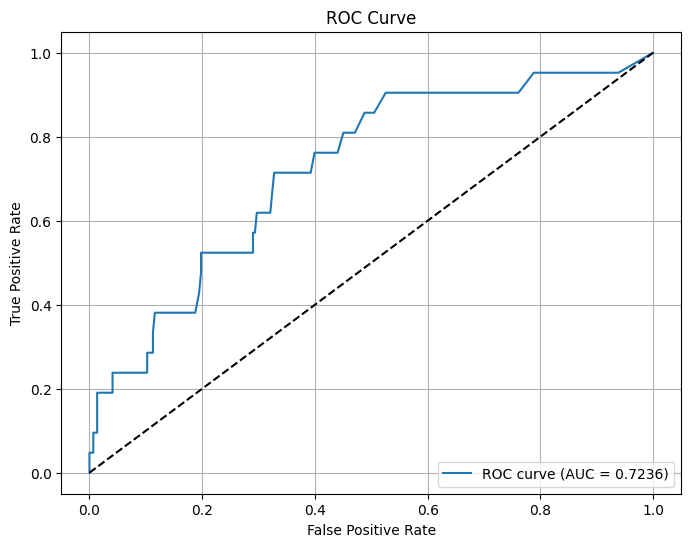

In [11]:
# Train model on balanced data
rf_balanced_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)
rf_balanced_model.fit(X_train_balanced, y_train_balanced.values.ravel())

# Evaluate against test selected set
y_pred = rf_balanced_model.predict(X_test_selected)

cm, total_cost = DataModeler().evaluate_model(y_test, y_pred, return_cm_cost=True)
print(f"Total cost = {total_cost}")

# Get predicted probabilities for class 1 and AUC/ROC analysis
y_proba = rf_balanced_model.predict_proba(X_test_selected)[:, 1]
DataModeler().auc_and_roc_curve(y_test, y_proba)

In [12]:
# # rf = RandomForestClassifier(
# #     n_estimators=300,
# #     random_state=42,
# #     class_weight="balanced",  # important for imbalance
# #     n_jobs=-1
# # )

# # rf.fit(X_train_balanced, y_train_balanced.values.ravel())
# y_pred = rf_model.predict(X_test_selected)

# cm, total_cost = DataModeler().evaluate_model(y_test, y_pred, return_cm_cost=True)
# print(f"Total cost = {total_cost}")

# # Get predicted probabilities for class 1 and AUC/ROC analysis
# y_proba = rf_model.predict_proba(X_test_selected)[:, 1]
# DataModeler().auc_and_roc_curve(y_test, y_proba)

In [ ]:
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 5, 10],
    "min_samples_leaf": [1, 3, 5],
    "class_weight": ["balanced", {0:1, 1:3}, {0:1, 1:5}]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring="recall",          # focus on detecting faulty wavers
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_balanced, y_train_balanced.values.ravel())

print("Best params:", grid.best_params_)
print("Best CV recall:", grid.best_score_)
best_model = grid.best_estimator_


Fitting 5 folds for each of 135 candidates, totalling 675 fits
Best params: {'class_weight': {0: 1, 1: 10}, 'max_depth': 5, 'min_samples_leaf': 3, 'n_estimators': 200}
Best CV recall: 0.9982905982905983


Accuracy: 0.5095541401273885

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.50      0.66       293
           1       0.08      0.62      0.14        21

    accuracy                           0.51       314
   macro avg       0.52      0.56      0.40       314
weighted avg       0.89      0.51      0.62       314


Confusion Matrix:
 [[147 146]
 [  8  13]] 



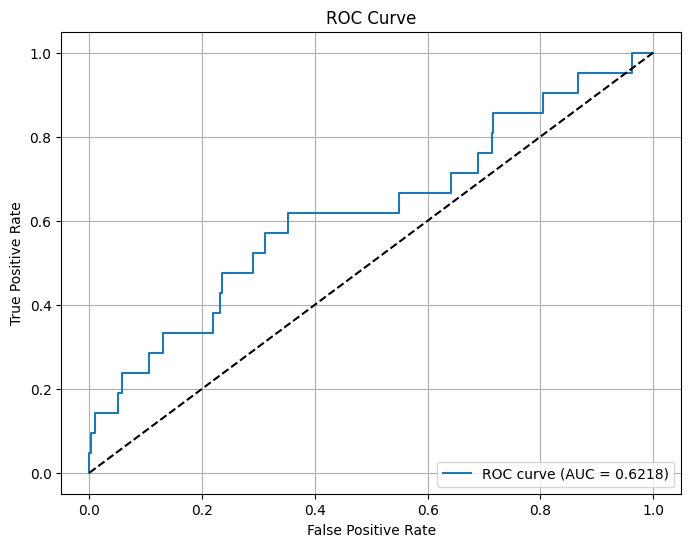

In [18]:
y_pred_best = best_model.predict(X_test_selected)
cm_best, total_cost_best = DataModeler().evaluate_model(y_test, y_pred_best, return_cm_cost=True)

# Get predicted probabilities for class 1 and AUC/ROC analysis
y_proba = best_model.predict_proba(X_test_selected)[:, 1]
DataModeler().auc_and_roc_curve(y_test, y_proba)

In [15]:
# y_proba = best_model.predict_proba(X_val_split)[:, 1]  # probability of class 1

# def evaluate_threshold(threshold):
#     y_pred_thr = (y_proba >= threshold).astype(int)
#     _, cost = DataModeler().evaluate_model(y_val_split, y_pred_thr, evaluation_report=False, return_cm_cost=True)
#     print(f"Threshold {threshold:.2f} -> total cost {cost}")
#     return cost

# thresholds = np.linspace(0.05, 0.95, 19)
# results = []

# for thr in thresholds:
#     cost = evaluate_threshold(thr)
#     results.append((thr, cost))

# for thr, cost in results:
#     print(f"Threshold {thr:.2f} -> total cost {cost}")

    
# best_thr, best_cost = min(results, key=lambda x: x[1])
# print(f"\nBest threshold by cost: {best_thr:.2f} with total cost {best_cost}")


In [16]:
# y_test_proba = best_model.predict_proba(X_test_selected)[:, 1]
# y_test_pred = (y_test_proba >= best_thr).astype(int)

# cm, total_cost = DataModeler().evaluate_model(y_test, y_test_pred, return_cm_cost=True)

In [ ]:
def main():
    